In [2]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

model = joblib.load("../results/model_logreg.pkl")
tfidf = joblib.load("../results/tfidf_vectorizer.pkl")
X_test, y_test, y_pred = joblib.load("../results/test_outputs.pkl")

print("Model ve test çıktıları yüklendi.")

Model ve test çıktıları yüklendi.


In [3]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.890625


In [4]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.86      0.89       160
           1       0.87      0.92      0.89       160

    accuracy                           0.89       320
   macro avg       0.89      0.89      0.89       320
weighted avg       0.89      0.89      0.89       320



In [5]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[138  22]
 [ 13 147]]


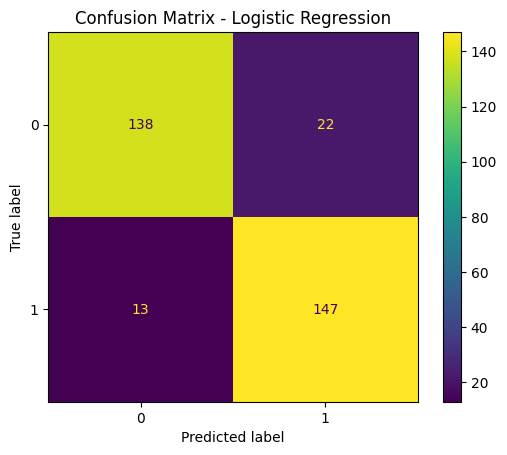

In [6]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [7]:
report = classification_report(y_test, y_pred)

with open("../results/metrics/evaluation_summary.txt", "w") as f:
    f.write(f"Accuracy: {accuracy}\n\n")
    f.write("Classification Report:\n")
    f.write(report)
    f.write("\nConfusion Matrix:\n")
    f.write(str(cm))

print("Evaluation summary kaydedildi.")

Evaluation summary kaydedildi.


In [8]:
eval_df = pd.DataFrame({
    "text": X_test.values,
    "true_label": y_test.values,
    "pred_label": y_pred
})

eval_df.head()

,text,true_label,pred_label
0,my stay at this hotel was one of the best i ha...,1,1
1,this hotel was everything we were looking for ...,1,1
2,i had reservations to check into the chicago c...,1,1
3,we stayed two nights we were registered by a v...,0,0
4,hi i had very bad experience with this hotel a...,1,1


In [9]:
wrong_preds = eval_df[eval_df["true_label"] != eval_df["pred_label"]]
print("Yanlış tahmin sayısı:", len(wrong_preds))
wrong_preds.head(10)

Yanlış tahmin sayısı: 35


,text,true_label,pred_label
22,i had a great experience staying at the conrad...,1,0
24,in the windy city this is a very good place am...,0,1
41,the room was very pretty and the location is g...,1,0
45,overall i had a very bad experience when hosti...,0,1
67,we experienced bed bugs in our room while stay...,0,1
82,conrad chicago it was am my plan just flew in ...,1,0
83,an excellent vacation destination clean rooms ...,1,0
88,great hotel went to see the museum of contempo...,1,0
89,i was really expecting a lot more from a quali...,1,0
94,i stayed affinia for one night on a purpose no...,0,1


<Figure size 600x500 with 0 Axes>

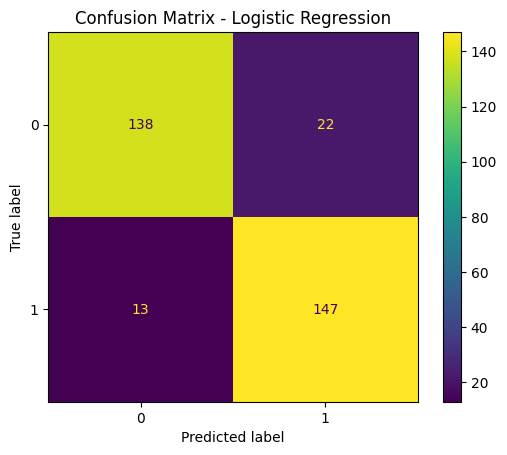

In [11]:
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.savefig("../results/figures/confusion_matrix_logreg.png", bbox_inches="tight")
plt.show()

In [12]:
wrong_preds[["text", "true_label", "pred_label"]].head(10)

,text,true_label,pred_label
22,i had a great experience staying at the conrad...,1,0
24,in the windy city this is a very good place am...,0,1
41,the room was very pretty and the location is g...,1,0
45,overall i had a very bad experience when hosti...,0,1
67,we experienced bed bugs in our room while stay...,0,1
82,conrad chicago it was am my plan just flew in ...,1,0
83,an excellent vacation destination clean rooms ...,1,0
88,great hotel went to see the museum of contempo...,1,0
89,i was really expecting a lot more from a quali...,1,0
94,i stayed affinia for one night on a purpose no...,0,1


In [13]:
for i, row in wrong_preds.head(5).iterrows():
    print(f"Index: {i}")
    print(f"True Label: {row['true_label']}, Pred Label: {row['pred_label']}")
    print(row["text"])
    print("-" * 80)

Index: 22
True Label: 1, Pred Label: 0
i had a great experience staying at the conrad chicago the service was top notch the price was good but out of everything the service was outstanding i would definitely stay there again when in the area and would suggest it to anyone looking for a good quality hotel in a great location right next to the shops at north bridge
--------------------------------------------------------------------------------
Index: 24
True Label: 0, Pred Label: 1
in the windy city this is a very good place amazing rooms and service everything is a walking distance an absolute must for business trio as ease with which you can conduct and schedule meetings here is unbeatable good decor and impishly modern
--------------------------------------------------------------------------------
Index: 41
True Label: 1, Pred Label: 0
the room was very pretty and the location is great but the hotel is so big and they don t have the staff to take care of everything the heating in ou